### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data (5 years)

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("AAPL")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-23,119.353447,121.009237,118.963847,120.122905,95467100
1,2021-03-24,116.967110,119.704042,116.947633,119.626121,88530500
2,2021-03-25,117.454109,118.496291,115.905460,116.431418,98844700
3,2021-03-26,118.058006,118.320989,115.827555,117.220369,94071200
4,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200


### Plot stock data

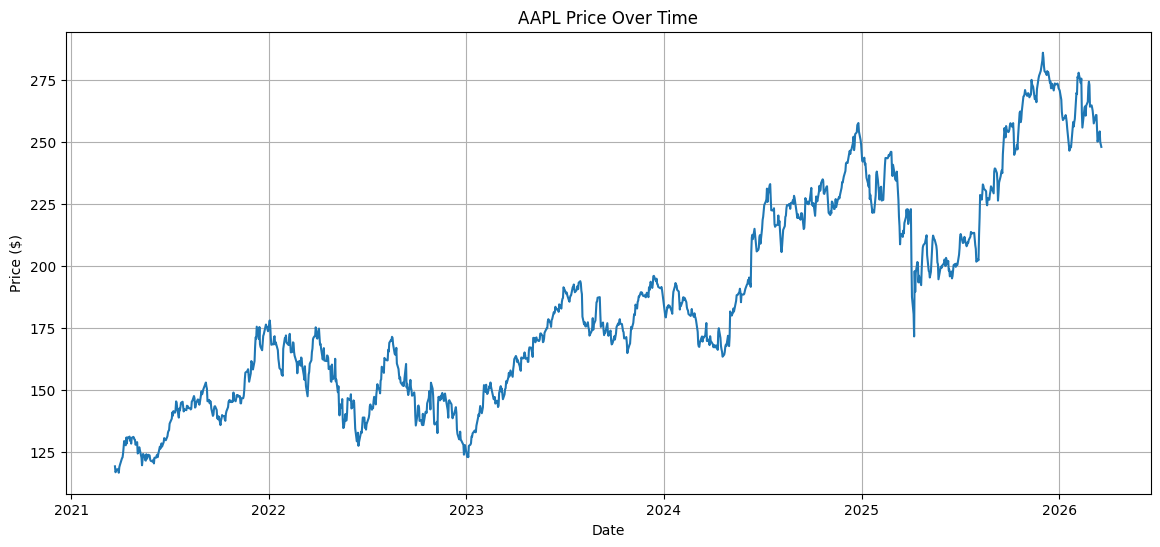

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.show()

### Plot the 9, 21, and 100 EMAs

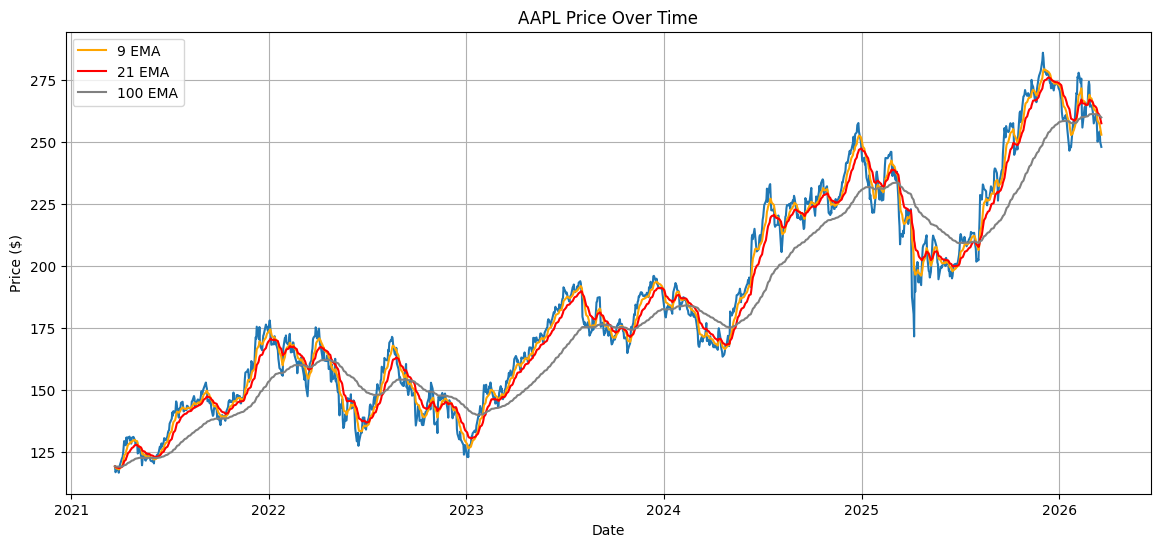

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Use a 70/30 train/test split

In [6]:
df.shape

(1255, 9)

In [7]:
split = int(len(df) * 0.7)
train = df[:split]
test = df[split:]

In [8]:
print(train.shape)
train.head()

(878, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
0,2021-03-23,119.353447,121.009237,118.963847,120.122905,95467100,119.353447,119.353447,119.353447
1,2021-03-24,116.967110,119.704042,116.947633,119.626121,88530500,118.876180,119.136507,119.306193
2,2021-03-25,117.454109,118.496291,115.905460,116.431418,98844700,118.591765,118.983562,119.269518
3,2021-03-26,118.058006,118.320989,115.827555,117.220369,94071200,118.485014,118.899421,119.245528
4,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200,118.434675,118.838866,119.225484


In [9]:
print(test.shape)
test.head()

(377, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
878,2024-09-18,219.249771,221.256593,216.120319,216.130263,59894900,219.052141,220.191654,209.875365
879,2024-09-19,227.376373,228.320186,223.164054,223.521705,66781300,220.716987,220.844810,210.221919
880,2024-09-20,226.710770,231.568857,226.134553,228.469223,318679900,221.915744,221.378079,210.548431
881,2024-09-23,224.992035,227.952583,224.336339,225.856352,54146000,222.531002,221.706621,210.834443
882,2024-09-24,225.886154,227.853243,224.256858,227.157800,43556100,223.202032,222.086578,211.132497


### Normalize the dataset

In [10]:
from sklearn.preprocessing import MinMaxScaler

In [11]:
# MinMaxScaler has default param feature_range=(0,1)
scaler = MinMaxScaler()

train_close = train[["Close"]]
test_close = test[["Close"]]

# Scale training data
train_close_scaled = scaler.fit_transform(train_close)

# Scale testing data
prev_20_close = train_close.tail(20)
test_close = pd.concat([prev_20_close, test_close], ignore_index=True)
test_close_scaled = scaler.transform(test_close)

In [12]:
print(train_close_scaled[:5])
print(train_close_scaled[-5:])

[[0.02212217]
 [0.00159203]
 [0.00578179]
 [0.01097723]
 [0.01248551]]
[[0.8983882 ]
 [0.89932826]
 [0.89702045]
 [0.84419995]
 [0.84821695]]


In [13]:
print(test_close_scaled[:5])
print(test_close_scaled[-5:])

[[0.93129437]
 [0.93035418]
 [0.91437099]
 [0.93411467]
 [0.93702056]]
[[1.17036193]
 [1.18249235]
 [1.14558467]
 [1.13715357]
 [1.12880845]]


### Create training sequences

In [14]:
x_train = []
y_train = []

# For each price x, grab the 20 prices before it and add them as a singular (list) element to x_train. Add price x as an element to y_train.
for i in range(20, train_close_scaled.shape[0]):
    x_train.append(train_close_scaled[i - 20 : i])
    y_train.append(train_close_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(858, 20, 1)
(858,)


### Create testing sequences

In [15]:
x_test = []
y_test = []

for i in range(20, test_close_scaled.shape[0]):
    x_test.append(test_close_scaled[i - 20 : i])
    y_test.append(test_close_scaled[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(377, 20, 1)
(377,)


### Build LSTM model

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [17]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], 1)))

model.add(LSTM(units=50, activation="relu", return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation="relu", return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation="relu", return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 60)         │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20, 80)         │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [18]:
import tensorflow as tf

In [19]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

model.fit(x_train, y_train, epochs=100)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0712 - mean_absolute_error: 0.2048
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0153 - mean_absolute_error: 0.0963
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0157 - mean_absolute_error: 0.0955
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0113 - mean_absolute_error: 0.0826
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0114 - mean_absolute_error: 0.0826
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0100 - mean_absolute_error: 0.0788
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0098 - mean_absolute_error: 0.0777
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0106 - mean_absolute_error: 0.0795
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0091 - mean_absolute_error: 0.0762
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0092 - mean_absolute_error: 0.0754
Epoch 11/100
27/27 ━━━━━━━━━━

### Make prediction

In [20]:
y_pred = model.predict(x_test)
print(y_pred.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
(377, 1)


In [21]:
print(y_test[:10])

[0.88155041 0.95146521 0.94573889 0.93095227 0.93864456 0.9300978
 0.93992671 0.94223439 0.98676465 0.92873005]


In [22]:
print(y_pred[:10])

[[0.8607538 ]
 [0.85601985]
 [0.867205  ]
 [0.88646734]
 [0.90210295]
 [0.91103566]
 [0.9131322 ]
 [0.91248083]
 [0.9117243 ]
 [0.91890085]]


### Plot prediction

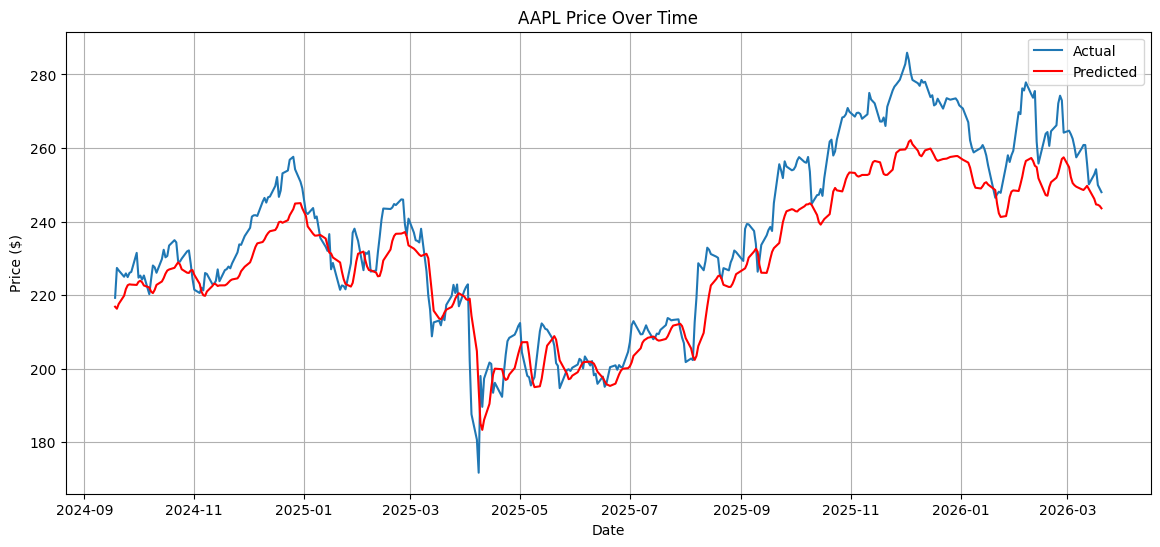

In [23]:
y_pred_prices = scaler.inverse_transform(y_pred)
y_test_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(test["Date"], y_test_prices, label="Actual")
plt.plot(test["Date"], y_pred_prices, label="Predicted", color="red")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.legend()